# **Machine Learning Jet Tempur**

Notebook ini digunakan untuk membandingkan model Machine Learning **tanpa fuzzy** dan **dengan fuzzy score**.

Eksperimen yang dijalankan:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

Setiap algoritma diuji dalam dua skenario:

- **Without Fuzzy**: menggunakan 5 fitur asli.
- **With Fuzzy**: menggunakan 5 fitur asli + `mamdani_score` + `sugeno_score`.

Catatan:
- Tidak dilakukan balancing/undersampling.
- Tidak dilakukan scaling karena fitur numerik utama berada pada rentang yang seragam.

## **0. Import Library**

In [1]:
!pip install -q xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

## **1. Load Dataset**

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train_hybrid = pd.read_csv("train_hybrid.csv")
test_hybrid = pd.read_csv("test_hybrid.csv")

print("Train shape        :", train.shape)
print("Test shape         :", test.shape)
print("Train hybrid shape :", train_hybrid.shape)
print("Test hybrid shape  :", test_hybrid.shape)

display(train.head())
display(train_hybrid.head())

Train shape        : (103904, 6)
Test shape         : (25976, 6)
Train hybrid shape : (103904, 8)
Test hybrid shape  : (25976, 8)


,Type of Travel,Class,Inflight wifi service,Online boarding,Inflight entertainment,satisfaction
0,Personal Travel,Eco Plus,3,3,5,neutral or dissatisfied
1,Business travel,Business,3,3,1,neutral or dissatisfied
2,Business travel,Business,2,5,5,satisfied
3,Business travel,Business,2,2,2,neutral or dissatisfied
4,Business travel,Business,3,5,3,satisfied


,Type of Travel,Class,Inflight wifi service,Online boarding,Inflight entertainment,satisfaction,mamdani_score,sugeno_score
0,Personal Travel,Eco Plus,3,3,5,neutral or dissatisfied,51.052953,60.714286
1,Business travel,Business,3,3,1,neutral or dissatisfied,51.052953,58.333333
2,Business travel,Business,2,5,5,satisfied,83.666667,75.000000
3,Business travel,Business,2,2,2,neutral or dissatisfied,48.947047,45.000000
4,Business travel,Business,3,5,3,satisfied,83.666667,75.000000


## **2. Validasi Dataset**

In [3]:
print("Missing value train:")
display(train.isnull().sum())

print("Missing value test:")
display(test.isnull().sum())

print("Missing value train_hybrid:")
display(train_hybrid.isnull().sum())

print("Missing value test_hybrid:")
display(test_hybrid.isnull().sum())

print("Distribusi target train:")
display(train["satisfaction"].value_counts(normalize=True).mul(100).round(2))

print("Distribusi target test:")
display(test["satisfaction"].value_counts(normalize=True).mul(100).round(2))

Missing value train:


,0
Type of Travel,0
Class,0
Inflight wifi service,0
Online boarding,0
Inflight entertainment,0
satisfaction,0


Missing value test:


,0
Type of Travel,0
Class,0
Inflight wifi service,0
Online boarding,0
Inflight entertainment,0
satisfaction,0


Missing value train_hybrid:


...

,0
Type of Travel,0
Class,0
Inflight wifi service,0
Online boarding,0
Inflight entertainment,0
satisfaction,0
mamdani_score,0
sugeno_score,0


Distribusi target train:


,proportion
satisfaction,
neutral or dissatisfied,56.67
satisfied,43.33


Distribusi target test:


,proportion
satisfaction,
neutral or dissatisfied,56.1
satisfied,43.9


## **3. Konfigurasi Fitur dan Target**

In [4]:
TARGET = "satisfaction"

FEATURES_ORIGINAL = [
    "Type of Travel",
    "Class",
    "Inflight wifi service",
    "Online boarding",
    "Inflight entertainment"
]

FEATURES_HYBRID = [
    "Type of Travel",
    "Class",
    "Inflight wifi service",
    "Online boarding",
    "Inflight entertainment",
    "mamdani_score",
    "sugeno_score"
]

CATEGORICAL_FEATURES = ["Type of Travel", "Class"]

print("Original features:", FEATURES_ORIGINAL)
print("Hybrid features  :", FEATURES_HYBRID)

Original features: ['Type of Travel', 'Class', 'Inflight wifi service', 'Online boarding', 'Inflight entertainment']
Hybrid features  : ['Type of Travel', 'Class', 'Inflight wifi service', 'Online boarding', 'Inflight entertainment', 'mamdani_score', 'sugeno_score']


## **4. Encode Label Target**

Label target perlu diubah menjadi angka karena model klasifikasi di scikit-learn dan XGBoost bekerja dengan target numerik.

Mapping yang digunakan:
- `neutral or dissatisfied` = 0
- `satisfied` = 1

In [5]:
label_encoder = LabelEncoder()

y_train_original = label_encoder.fit_transform(train[TARGET])
y_test_original = label_encoder.transform(test[TARGET])

y_train_hybrid = label_encoder.transform(train_hybrid[TARGET])
y_test_hybrid = label_encoder.transform(test_hybrid[TARGET])

print("Label mapping:")
for label, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{label} -> {encoded}")

Label mapping:
neutral or dissatisfied -> 0
satisfied -> 1


## **5. Fungsi Preprocessing, Evaluasi, dan Eksperimen**

In [6]:
def build_preprocessor():
    """
    OneHotEncoder digunakan untuk fitur kategorikal.
    Fitur numerik dilewatkan apa adanya dengan remainder='passthrough'.
    """
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)
        ],
        remainder="passthrough"
    )


def evaluate_prediction(y_true, y_pred):
    """Menghasilkan metrik evaluasi klasifikasi biner."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }


def run_experiment(model_name, estimator, X_train, y_train, X_test, y_test):
    """Membangun pipeline, training model, prediksi, dan evaluasi."""
    pipeline = Pipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("classifier", clone(estimator))
        ]
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    metrics = evaluate_prediction(y_test, y_pred)
    metrics["Model"] = model_name

    print(f"===== {model_name} =====")
    print("Accuracy :", round(metrics["Accuracy"], 4))
    print("Precision:", round(metrics["Precision"], 4))
    print("Recall   :", round(metrics["Recall"], 4))
    print("F1 Score :", round(metrics["F1 Score"], 4))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return pipeline, y_pred, metrics

## **6. Definisi Model**

In [7]:
MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

## **7. Siapkan Data Original dan Hybrid**

In [8]:
X_train_original = train[FEATURES_ORIGINAL]
X_test_original = test[FEATURES_ORIGINAL]

X_train_hybrid = train_hybrid[FEATURES_HYBRID]
X_test_hybrid = test_hybrid[FEATURES_HYBRID]

print("X_train_original:", X_train_original.shape)
print("X_test_original :", X_test_original.shape)
print("X_train_hybrid  :", X_train_hybrid.shape)
print("X_test_hybrid   :", X_test_hybrid.shape)

X_train_original: (103904, 5)
X_test_original : (25976, 5)
X_train_hybrid  : (103904, 7)
X_test_hybrid   : (25976, 7)


## **8. Eksperimen Semua Model**

In [9]:
trained_models = {}
predictions = {}
results = []

for base_model_name, estimator in MODELS.items():
    # Without Fuzzy
    model_name_original = f"{base_model_name} Without Fuzzy"
    pipeline_original, y_pred_original, metrics_original = run_experiment(
        model_name=model_name_original,
        estimator=estimator,
        X_train=X_train_original,
        y_train=y_train_original,
        X_test=X_test_original,
        y_test=y_test_original
    )

    trained_models[model_name_original] = pipeline_original
    predictions[model_name_original] = y_pred_original
    results.append(metrics_original)

    print("\n" + "-" * 80 + "\n")

    # With Fuzzy
    model_name_hybrid = f"{base_model_name} With Fuzzy"
    pipeline_hybrid, y_pred_hybrid, metrics_hybrid = run_experiment(
        model_name=model_name_hybrid,
        estimator=estimator,
        X_train=X_train_hybrid,
        y_train=y_train_hybrid,
        X_test=X_test_hybrid,
        y_test=y_test_hybrid
    )

    trained_models[model_name_hybrid] = pipeline_hybrid
    predictions[model_name_hybrid] = y_pred_hybrid
    results.append(metrics_hybrid)

    print("\n" + "=" * 100 + "\n")

===== Logistic Regression Without Fuzzy =====
Accuracy : 0.8407
Precision: 0.8157
Recall   : 0.823
F1 Score : 0.8194

Classification Report:
                         precision    recall  f1-score   support

neutral or dissatisfied       0.86      0.85      0.86     14573
              satisfied       0.82      0.82      0.82     11403

               accuracy                           0.84     25976
              macro avg       0.84      0.84      0.84     25976
           weighted avg       0.84      0.84      0.84     25976


Confusion Matrix:
[[12453  2120]
 [ 2018  9385]]

--------------------------------------------------------------------------------

===== Logistic Regression With Fuzzy =====
Accuracy : 0.8442
Precision: 0.8189
Recall   : 0.8281
F1 Score : 0.8235

Classification Report:
                         precision    recall  f1-score   support

neutral or dissatisfied       0.86      0.86      0.86     14573
              satisfied       0.82      0.83      0.82     1140

## **9. Tabel Perbandingan Model**

In [10]:
comparison_models = pd.DataFrame(results)

comparison_models = comparison_models[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
]

display(comparison_models.sort_values(by="Accuracy", ascending=False))

,Model,Accuracy,Precision,Recall,F1 Score
5,Random Forest With Fuzzy,0.925316,0.929317,0.898185,0.913486
4,Random Forest Without Fuzzy,0.925316,0.929317,0.898185,0.913486
7,XGBoost With Fuzzy,0.925200,0.929531,0.897659,0.913317
6,XGBoost Without Fuzzy,0.921851,0.926705,0.892572,0.909318
3,Decision Tree With Fuzzy,0.905528,0.891778,0.893186,0.892482
2,Decision Tree Without Fuzzy,0.896789,0.917560,0.840393,0.877283
1,Logistic Regression With Fuzzy,0.844164,0.818923,0.828115,0.823494
0,Logistic Regression Without Fuzzy,0.840699,0.815732,0.823029,0.819364


## **10. Perbandingan Original vs Hybrid**

In [11]:
comparison_delta = []

for base_model_name in MODELS.keys():
    without_fuzzy = comparison_models[
        comparison_models["Model"] == f"{base_model_name} Without Fuzzy"
    ].iloc[0]

    with_fuzzy = comparison_models[
        comparison_models["Model"] == f"{base_model_name} With Fuzzy"
    ].iloc[0]

    comparison_delta.append({
        "Model": base_model_name,
        "Accuracy Without Fuzzy": without_fuzzy["Accuracy"],
        "Accuracy With Fuzzy": with_fuzzy["Accuracy"],
        "Accuracy Delta": with_fuzzy["Accuracy"] - without_fuzzy["Accuracy"],
        "F1 Without Fuzzy": without_fuzzy["F1 Score"],
        "F1 With Fuzzy": with_fuzzy["F1 Score"],
        "F1 Delta": with_fuzzy["F1 Score"] - without_fuzzy["F1 Score"]
    })

comparison_delta = pd.DataFrame(comparison_delta)
display(comparison_delta)

,Model,Accuracy Without Fuzzy,Accuracy With Fuzzy,Accuracy Delta,F1 Without Fuzzy,F1 With Fuzzy,F1 Delta
0,Logistic Regression,0.840699,0.844164,0.003465,0.819364,0.823494,0.004129
1,Decision Tree,0.896789,0.905528,0.008739,0.877283,0.892482,0.015199
2,Random Forest,0.925316,0.925316,0.000000,0.913486,0.913486,0.000000
3,XGBoost,0.921851,0.925200,0.003349,0.909318,0.913317,0.003999


## **11. Visualisasi Perbandingan Model**

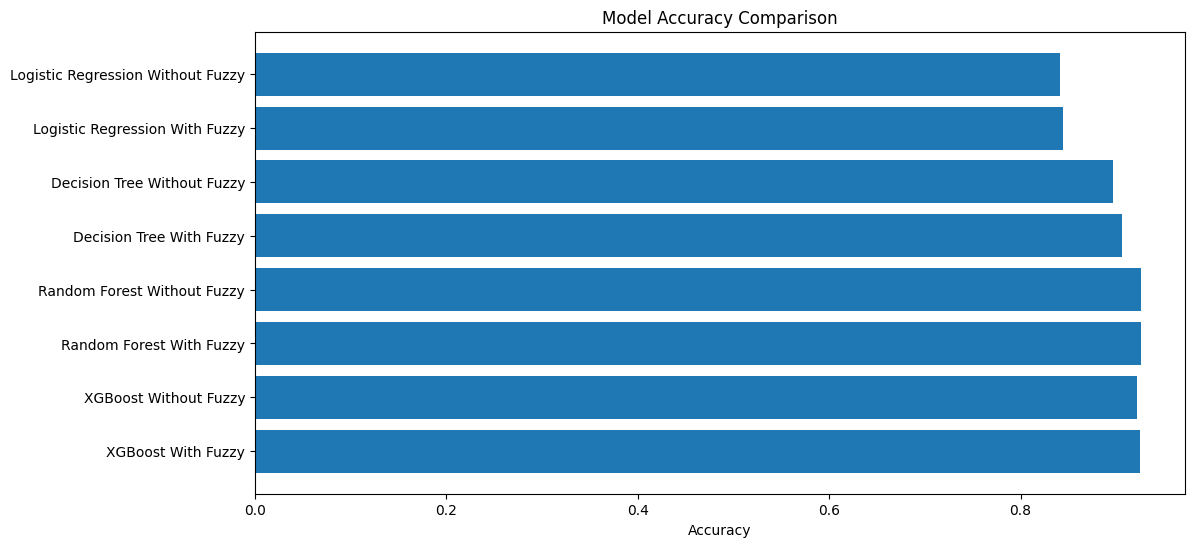

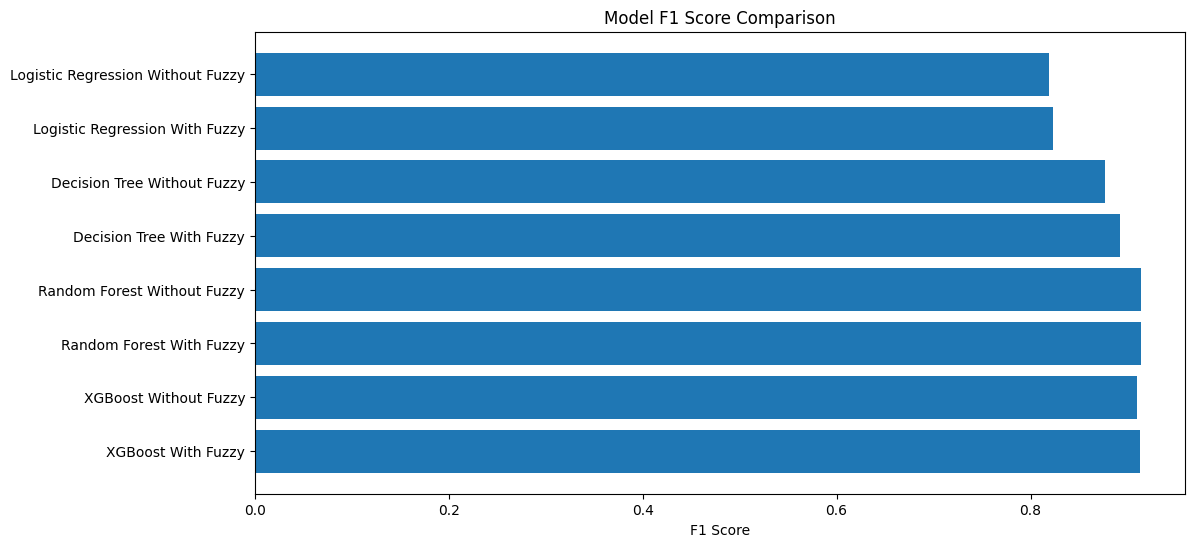

In [12]:
plt.figure(figsize=(12, 6))
plt.barh(comparison_models["Model"], comparison_models["Accuracy"])
plt.xlabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(12, 6))
plt.barh(comparison_models["Model"], comparison_models["F1 Score"])
plt.xlabel("F1 Score")
plt.title("Model F1 Score Comparison")
plt.gca().invert_yaxis()
plt.show()

## **12. Export Model**

In [13]:
EXPORT_DIR = "exported_model"
os.makedirs(EXPORT_DIR, exist_ok=True)

final_model_name = "Random Forest With Fuzzy"
final_model = trained_models[final_model_name]

joblib.dump(final_model, f"{EXPORT_DIR}/rf_fuzzy_model.pkl")
joblib.dump(label_encoder, f"{EXPORT_DIR}/label_encoder.pkl")
joblib.dump(FEATURES_HYBRID, f"{EXPORT_DIR}/features_hybrid.pkl")

print("Model berhasil diekspor:")
print(f"- {EXPORT_DIR}/rf_fuzzy_model.pkl")
print(f"- {EXPORT_DIR}/label_encoder.pkl")
print(f"- {EXPORT_DIR}/features_hybrid.pkl")

Model berhasil diekspor:
- exported_model/rf_fuzzy_model.pkl
- exported_model/label_encoder.pkl
- exported_model/features_hybrid.pkl
